# Phase 3 — One-Driver Stochastic Radius

This notebook verifies the Phase 3 construction

\[
X_t=X_0+\mu t+\sigma W_t,\qquad
Z_t=Z_0e^{(\alpha+i\beta)(X_t-X_0)}.
\]

The experiments check:

1. pathwise equivalence and exact multiplicative steps;
2. analytic radial and complex moments;
3. rank-one amplitude-phase covariance versus rank-two planar noise;
4. Euler–Maruyama strong convergence for the induced complex SDE;
5. the general covariance outer-product theorem;
6. Tanaka's formula and occupation-density approximation at zero.

All simulations use deterministic seeds. The notebook verifies
derivations from the accompanying Markdown notes; it does not replace
the proofs.

In [1]:
import os
import platform
import sys

import matplotlib
import matplotlib.pyplot as plt
import nbformat
import numpy as np
import scipy

BASE_SEED = 20260723
np.set_printoptions(precision=7, suppress=True)
plt.style.use("seaborn-v0_8-whitegrid")

print("Environment:", os.environ.get("CONDA_DEFAULT_ENV", "unknown"))
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("Matplotlib:", matplotlib.__version__)
print("nbformat:", nbformat.__version__)

Environment: base
Python: 3.13.9
Platform: Linux-7.1.4-1-cachyos-x86_64-with-glibc2.43
NumPy: 2.3.5
SciPy: 1.16.3
Matplotlib: 3.10.6
nbformat: 5.10.4


## 1. Exact pathwise logarithmic-spiral representation

Let \(c=\alpha+i\beta\). Itô's formula predicts

\[
\frac{dZ_t}{Z_t}
=
\left(c\mu+\frac12c^2\sigma^2\right)dt
+c\sigma\,dW_t.
\]

The radius is injective when \(\alpha\ne0\):

\[
X_t=X_0+\frac1\alpha\log\frac{|Z_t|}{|Z_0|}.
\]

On a grid, the induced complex random walk is exact:

\[
Z_{n+1}=Z_n e^{c\Delta X_n}.
\]

Maximum exact-product error: 6.273e-15
Maximum inverse-radius error: 1.110e-15
Maximum spiral-relation error: 9.437e-16


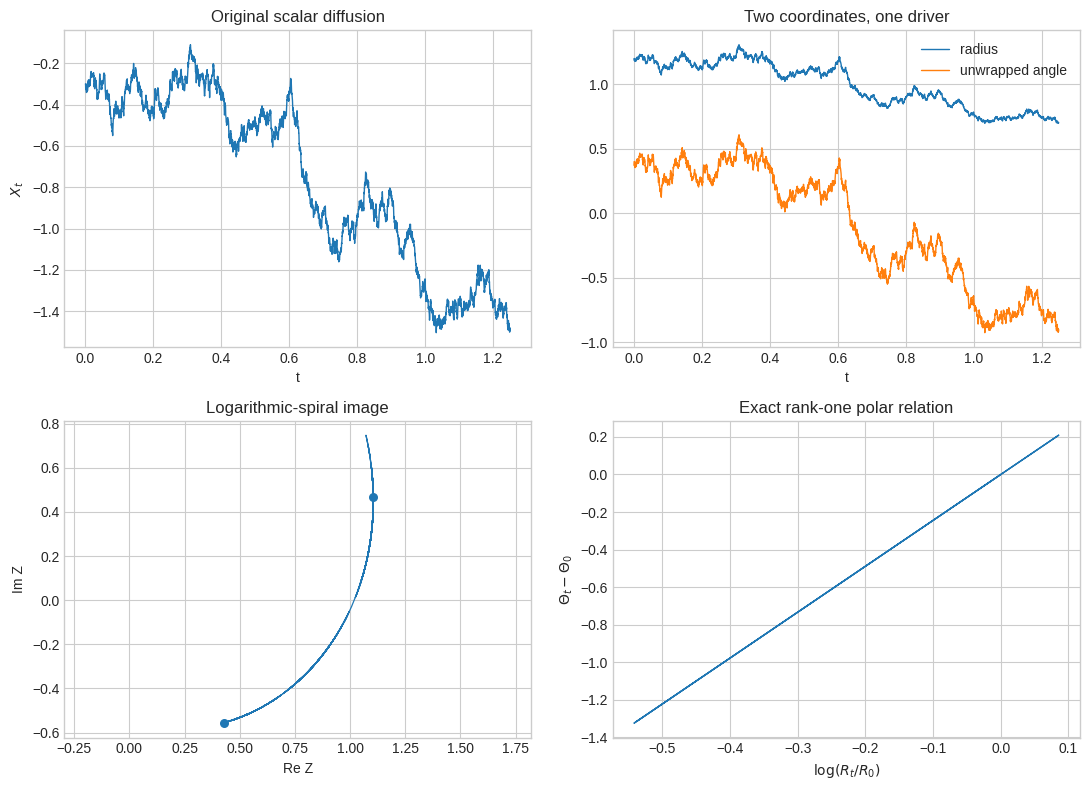

In [2]:
MU = 0.20
SIGMA = 0.65
ALPHA = 0.45
BETA = 1.10
C = ALPHA + 1j * BETA
X0 = -0.30
R0 = 1.20
THETA0 = 0.40
Z0 = R0 * np.exp(1j * THETA0)
T = 1.25

n_path = 4096
h_path = T / n_path
rng = np.random.default_rng(BASE_SEED)
dW = np.sqrt(h_path) * rng.standard_normal(n_path)
dX = MU * h_path + SIGMA * dW
X = X0 + np.concatenate(([0.0], np.cumsum(dX)))

Z_direct = Z0 * np.exp(C * (X - X0))
Z_product = Z0 * np.concatenate(
    ([1.0 + 0.0j], np.cumprod(np.exp(C * dX)))
)
X_from_radius = X0 + np.log(np.abs(Z_direct) / R0) / ALPHA
A = np.log(np.abs(Z_direct))
theta_unwrapped = THETA0 + BETA * (X - X0)

product_error = np.max(np.abs(Z_product - Z_direct))
inverse_error = np.max(np.abs(X_from_radius - X))
spiral_error = np.max(
    np.abs(
        (theta_unwrapped - THETA0)
        - (BETA / ALPHA) * (A - np.log(R0))
    )
)

print(f"Maximum exact-product error: {product_error:.3e}")
print(f"Maximum inverse-radius error: {inverse_error:.3e}")
print(f"Maximum spiral-relation error: {spiral_error:.3e}")

assert product_error < 2e-12
assert inverse_error < 2e-15
assert spiral_error < 2e-15

t_grid = np.linspace(0.0, T, n_path + 1)
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes[0, 0].plot(t_grid, X, lw=1)
axes[0, 0].set_title("Original scalar diffusion")
axes[0, 0].set_xlabel("t")
axes[0, 0].set_ylabel(r"$X_t$")

axes[0, 1].plot(t_grid, np.abs(Z_direct), lw=1, label="radius")
axes[0, 1].plot(t_grid, theta_unwrapped, lw=1, label="unwrapped angle")
axes[0, 1].set_title("Two coordinates, one driver")
axes[0, 1].set_xlabel("t")
axes[0, 1].legend()

axes[1, 0].plot(Z_direct.real, Z_direct.imag, lw=0.9)
axes[1, 0].scatter(
    [Z_direct[0].real, Z_direct[-1].real],
    [Z_direct[0].imag, Z_direct[-1].imag],
    s=30,
    zorder=3,
)
axes[1, 0].set_aspect("equal", adjustable="datalim")
axes[1, 0].set_title("Logarithmic-spiral image")
axes[1, 0].set_xlabel("Re Z")
axes[1, 0].set_ylabel("Im Z")

axes[1, 1].plot(A - np.log(R0), theta_unwrapped - THETA0, lw=1)
axes[1, 1].set_title("Exact rank-one polar relation")
axes[1, 1].set_xlabel(r"$\log(R_t/R_0)$")
axes[1, 1].set_ylabel(r"$\Theta_t-\Theta_0$")
plt.tight_layout()
plt.show()

## 2. Analytic moment checks

Since \(Y_t=X_t-X_0\sim N(\mu t,\sigma^2t)\),

\[
\mathbb E[R_t^p]
=
R_0^p
e^{p\alpha\mu t+\frac12p^2\alpha^2\sigma^2t},
\]

and

\[
\mathbb E\left[\left(\frac{Z_t}{Z_0}\right)^n\right]
=
e^{nc\mu t+\frac12n^2c^2\sigma^2t}.
\]

Standardized discrepancies below use the Monte Carlo standard error
of the corresponding real or imaginary sample mean.

In [3]:
n_mc = 250_000
rng = np.random.default_rng(BASE_SEED + 1)
terminal_y = MU * T + SIGMA * np.sqrt(T) * rng.standard_normal(n_mc)
terminal_ratio = np.exp(C * terminal_y)
terminal_radius = R0 * np.exp(ALPHA * terminal_y)

moment_rows = []
for p in (1, 2):
    samples = terminal_radius**p
    estimate = samples.mean()
    se = samples.std(ddof=1) / np.sqrt(n_mc)
    exact = R0**p * np.exp(
        p * ALPHA * MU * T
        + 0.5 * p**2 * ALPHA**2 * SIGMA**2 * T
    )
    z_score = (estimate - exact) / se
    moment_rows.append((f"E[R^{p}]", estimate, exact, se, z_score))

complex_rows = []
for n in (1, 2):
    samples = terminal_ratio**n
    estimate = samples.mean()
    exact = np.exp(
        n * C * MU * T + 0.5 * n**2 * C**2 * SIGMA**2 * T
    )
    se_real = samples.real.std(ddof=1) / np.sqrt(n_mc)
    se_imag = samples.imag.std(ddof=1) / np.sqrt(n_mc)
    z_real = (estimate.real - exact.real) / se_real
    z_imag = (estimate.imag - exact.imag) / se_imag
    complex_rows.append(
        (n, estimate, exact, se_real, se_imag, z_real, z_imag)
    )

print("Radial moments")
for name, estimate, exact, se, z_score in moment_rows:
    print(
        f"  {name}: estimate={estimate:.7f}, exact={exact:.7f}, "
        f"SE={se:.2e}, z={z_score:.3f}"
    )

print("Complex moments of Z/Z0")
for n, estimate, exact, se_r, se_i, z_r, z_i in complex_rows:
    print(
        f"  n={n}: estimate={estimate.real:.7f}{estimate.imag:+.7f}i, "
        f"exact={exact.real:.7f}{exact.imag:+.7f}i, "
        f"z=({z_r:.3f}, {z_i:.3f})"
    )

assert max(abs(row[4]) for row in moment_rows) < 4.5
assert max(
    max(abs(row[5]), abs(row[6])) for row in complex_rows
) < 4.5

Radial moments
  E[R^1]: estimate=1.4162073, exact=1.4166490, SE=9.51e-04, z=-0.465
  E[R^2]: estimate=2.2315513, exact=2.2334193, SE=3.25e-03, z=-0.575
Complex moments of Z/Z0
  n=1: estimate=0.7376586+0.4378687i, exact=0.7371989+0.4383209i, z=(0.484, -0.295)
  n=2: estimate=-0.0099133+0.4311182i, exact=-0.0107536+0.4319343i, z=(0.309, -0.318)


## 3. Rank-one versus rank-two covariance

The one-driver polar covariance is

\[
K
=
\sigma^2
\begin{pmatrix}
\alpha^2&\alpha\beta\\
\alpha\beta&\beta^2
\end{pmatrix}.
\]

Its eigenvalues are

\[
\sigma^2(\alpha^2+\beta^2),\qquad0.
\]

For comparison, isotropic planar Brownian motion at a fixed local
radius \(r\) has log-polar covariance

\[
\frac{\sigma^2}{r^2}I_2,
\]

with two positive eigenvalues.

One-driver empirical covariance / dt:
[[0.0854997 0.2089992]
 [0.2089992 0.510887 ]]
One-driver eigenvalues: [-0.         0.5963867]
One-driver relative covariance error: 6.6111e-04
Two-driver empirical covariance / dt:
[[ 0.2499651 -0.000049 ]
 [-0.000049   0.249299 ]]
Two-driver eigenvalues: [0.2492954 0.2499687]
Two-driver relative covariance error: 1.9950e-03


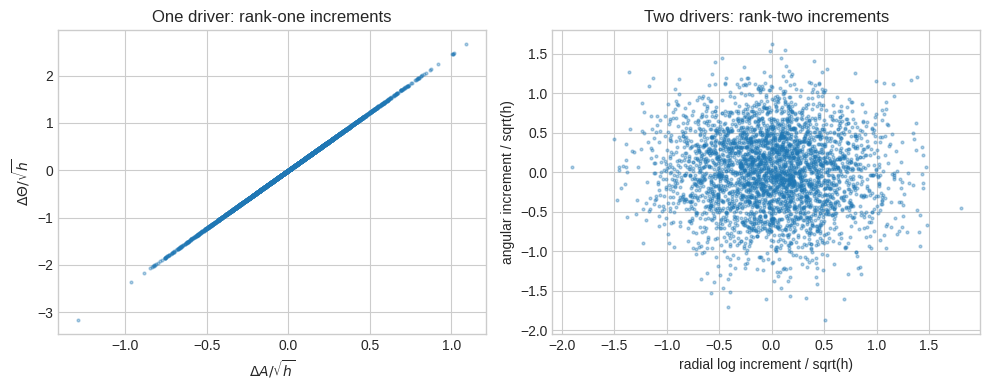

In [4]:
n_cov = 400_000
h_cov = 0.005
rng = np.random.default_rng(BASE_SEED + 2)
xi = rng.standard_normal(n_cov)
scalar_increment = MU * h_cov + SIGMA * np.sqrt(h_cov) * xi
dA = ALPHA * scalar_increment
dTheta = BETA * scalar_increment

empirical_rank1 = (
    np.cov(np.vstack((dA, dTheta)), bias=True) / h_cov
)
theory_rank1 = SIGMA**2 * np.array(
    [[ALPHA**2, ALPHA * BETA], [ALPHA * BETA, BETA**2]]
)
eig_rank1 = np.linalg.eigvalsh(empirical_rank1)
rank1_relative_error = (
    np.linalg.norm(empirical_rank1 - theory_rank1)
    / np.linalg.norm(theory_rank1)
)

local_radius = 1.30
xi_planar = rng.standard_normal((2, n_cov))
planar_increment = (
    SIGMA * np.sqrt(h_cov) / local_radius * xi_planar
)
empirical_rank2 = np.cov(planar_increment, bias=True) / h_cov
theory_rank2 = (SIGMA**2 / local_radius**2) * np.eye(2)
eig_rank2 = np.linalg.eigvalsh(empirical_rank2)
rank2_relative_error = (
    np.linalg.norm(empirical_rank2 - theory_rank2)
    / np.linalg.norm(theory_rank2)
)

print("One-driver empirical covariance / dt:")
print(empirical_rank1)
print("One-driver eigenvalues:", eig_rank1)
print(f"One-driver relative covariance error: {rank1_relative_error:.4e}")
print("Two-driver empirical covariance / dt:")
print(empirical_rank2)
print("Two-driver eigenvalues:", eig_rank2)
print(f"Two-driver relative covariance error: {rank2_relative_error:.4e}")

assert rank1_relative_error < 0.01
assert abs(eig_rank1[0]) < 1e-12
assert eig_rank1[1] > 0.99 * SIGMA**2 * (ALPHA**2 + BETA**2)
assert rank2_relative_error < 0.01
assert eig_rank2[0] > 0.98 * SIGMA**2 / local_radius**2

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
subset = slice(0, 3500)
axes[0].scatter(
    dA[subset] / np.sqrt(h_cov),
    dTheta[subset] / np.sqrt(h_cov),
    s=4,
    alpha=0.35,
)
axes[0].set_title("One driver: rank-one increments")
axes[0].set_xlabel(r"$\Delta A/\sqrt{h}$")
axes[0].set_ylabel(r"$\Delta\Theta/\sqrt{h}$")

axes[1].scatter(
    planar_increment[0, subset] / np.sqrt(h_cov),
    planar_increment[1, subset] / np.sqrt(h_cov),
    s=4,
    alpha=0.35,
)
axes[1].set_title("Two drivers: rank-two increments")
axes[1].set_xlabel("radial log increment / sqrt(h)")
axes[1].set_ylabel("angular increment / sqrt(h)")
plt.tight_layout()
plt.show()

## 4. Euler–Maruyama strong convergence

The induced linear complex SDE is

\[
dZ_t=\lambda Z_tdt+\nu Z_tdW_t,
\]

where

\[
\lambda=c\mu+\frac12c^2\sigma^2,
\qquad
\nu=c\sigma.
\]

Its exact solution is \(Z_t=Z_0e^{c(\mu t+\sigma W_t)}\).
Every resolution below is coupled through the same finest Brownian
paths.

Euler–Maruyama strong errors
  N= 16, h=0.0781250, mean error=1.4986753e-01, SE=1.15e-03
  N= 32, h=0.0390625, mean error=1.0650886e-01, SE=7.78e-04
  N= 64, h=0.0195312, mean error=7.5144605e-02, SE=5.45e-04
  N=128, h=0.0097656, mean error=5.2677443e-02, SE=3.68e-04
  N=256, h=0.0048828, mean error=3.7240809e-02, SE=2.56e-04
  N=512, h=0.0024414, mean error=2.6345962e-02, SE=1.84e-04
Estimated strong convergence slope: 0.5029


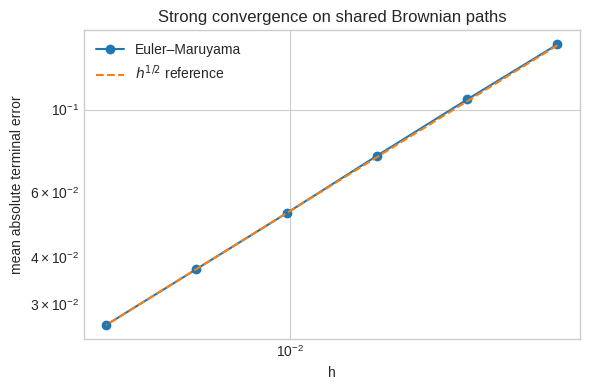

In [5]:
lambda_complex = C * MU + 0.5 * C**2 * SIGMA**2
nu_complex = C * SIGMA
n_em_paths = 15_000
n_fine = 512
rng = np.random.default_rng(BASE_SEED + 3)
dW_fine = (
    np.sqrt(T / n_fine)
    * rng.standard_normal((n_em_paths, n_fine))
)
W_T = dW_fine.sum(axis=1)
exact_terminal = Z0 * np.exp(C * (MU * T + SIGMA * W_T))

em_steps = np.array([16, 32, 64, 128, 256, 512])
em_h = T / em_steps
em_errors = []
em_ses = []

for n_steps in em_steps:
    group = n_fine // n_steps
    coarse_dW = dW_fine.reshape(
        n_em_paths, n_steps, group
    ).sum(axis=2)
    z_em = np.full(n_em_paths, Z0, dtype=complex)
    h = T / n_steps
    for k in range(n_steps):
        z_em *= (
            1.0
            + lambda_complex * h
            + nu_complex * coarse_dW[:, k]
        )
    path_errors = np.abs(z_em - exact_terminal)
    em_errors.append(path_errors.mean())
    em_ses.append(path_errors.std(ddof=1) / np.sqrt(n_em_paths))

em_errors = np.asarray(em_errors)
em_ses = np.asarray(em_ses)
em_slope = np.polyfit(np.log(em_h), np.log(em_errors), 1)[0]

print("Euler–Maruyama strong errors")
for n_steps, h, error, se in zip(
    em_steps, em_h, em_errors, em_ses
):
    print(
        f"  N={n_steps:3d}, h={h:.7f}, "
        f"mean error={error:.7e}, SE={se:.2e}"
    )
print(f"Estimated strong convergence slope: {em_slope:.4f}")

assert np.all(np.diff(em_errors) < 0)
assert 0.42 < em_slope < 0.62

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(em_h, em_errors, "o-", label="Euler–Maruyama")
reference = em_errors[-1] * (em_h / em_h[-1]) ** 0.5
ax.loglog(em_h, reference, "--", label=r"$h^{1/2}$ reference")
ax.set_xlabel("h")
ax.set_ylabel("mean absolute terminal error")
ax.set_title("Strong convergence on shared Brownian paths")
ax.legend()
plt.tight_layout()
plt.show()

del dW_fine

## 5. General deterministic image and covariance rank

For \(F=(F_1,F_2):\mathbb R\to\mathbb R^2\),

\[
dF(X_t)
=
\left(\mu F'(X_t)+\frac12\sigma^2F''(X_t)\right)dt
+\sigma F'(X_t)dW_t.
\]

Its covariance is the outer product

\[
C_t=\sigma^2F'(X_t)F'(X_t)^{\mathsf T},
\]

and therefore has determinant zero for every smooth \(F\).

In [6]:
# A nonlinear example: F(x) = (x, 0.30 x^2 + 0.20 x).
x_test = 0.70
derivative = np.array([1.0, 0.60 * x_test + 0.20])
covariance_image = SIGMA**2 * np.outer(derivative, derivative)
image_eigenvalues = np.linalg.eigvalsh(covariance_image)
image_determinant = np.linalg.det(covariance_image)

print("Nonlinear-image derivative:", derivative)
print("Nonlinear-image covariance:")
print(covariance_image)
print("Eigenvalues:", image_eigenvalues)
print(f"Determinant: {image_determinant:.3e}")

assert abs(image_determinant) < 1e-14
assert abs(image_eigenvalues[0]) < 1e-14
assert image_eigenvalues[1] > 0

Nonlinear-image derivative: [1.   0.62]
Nonlinear-image covariance:
[[0.4225   0.26195 ]
 [0.26195  0.162409]]
Eigenvalues: [0.       0.584909]
Determinant: 7.058e-18


## 6. Tanaka local time at the scalar origin

For standard Brownian motion started at zero,

\[
|W_T|
=
\int_0^T\operatorname{sgn}(W_s)dW_s+L_T^0,
\qquad
\mathbb E[L_T^0]=\sqrt{\frac{2T}{\pi}}.
\]

On a grid, define the exact nonnegative crossing residual

\[
\ell_n
=
|W_{n+1}|-|W_n|
-\operatorname{sgn}(W_n)\Delta W_n.
\]

Its sum gives an exact discrete Tanaka identity. The occupation
estimator is

\[
\widehat L_{T,\varepsilon,h}^0
=
\frac1{2\varepsilon}
\sum_n\mathbf1_{\{|W_n|<\varepsilon\}}h.
\]

We use \(\varepsilon=0.5h^{1/4}\), so
\(\varepsilon\downarrow0\) while remaining wider than a typical grid
increment.

Exact E[L_T^0]: 0.8920621
  N= 128, eps=0.15718, discrete=0.8911254 (z=-0.151), occupation=0.8242986 (error=-0.0678), identity max=3.94e-15
  N= 512, eps=0.11114, discrete=0.8943396 (z=+0.371), occupation=0.8454725 (error=-0.0466), identity max=5.77e-15
  N=2048, eps=0.07859, discrete=0.8878201 (z=-0.686), occupation=0.8511989 (error=-0.0409), identity max=1.29e-14
  N=8192, eps=0.05557, discrete=0.9001265 (z=+1.298), occupation=0.8714687 (error=-0.0206), identity max=3.02e-14


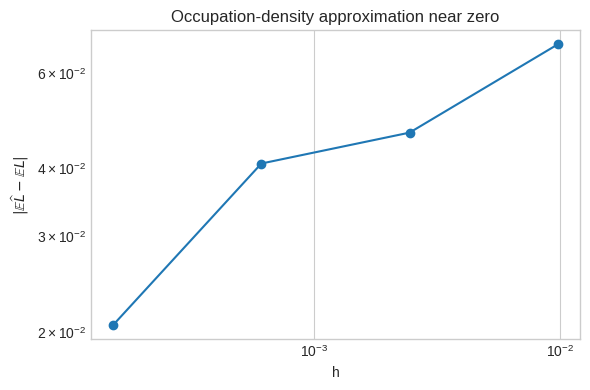

In [7]:
tanaka_steps = np.array([128, 512, 2048, 8192])
n_tanaka_paths = 12_000
tanaka_exact_mean = np.sqrt(2.0 * T / np.pi)
tanaka_rows = []

for n_steps in tanaka_steps:
    h = T / n_steps
    epsilon = 0.5 * h**0.25
    rng = np.random.default_rng(BASE_SEED + 10 + int(n_steps))
    x = np.zeros(n_tanaka_paths)
    ito_sum = np.zeros(n_tanaka_paths)
    local_discrete = np.zeros(n_tanaka_paths)
    occupation_time = np.zeros(n_tanaka_paths)

    for _ in range(n_steps):
        sign_x = np.sign(x)
        occupation_time += (np.abs(x) < epsilon) * h
        dx = np.sqrt(h) * rng.standard_normal(n_tanaka_paths)
        x_next = x + dx
        ito_sum += sign_x * dx
        local_discrete += (
            np.abs(x_next) - np.abs(x) - sign_x * dx
        )
        x = x_next

    local_occupation = occupation_time / (2.0 * epsilon)
    identity_error = np.max(
        np.abs(np.abs(x) - ito_sum - local_discrete)
    )
    discrete_mean = local_discrete.mean()
    discrete_se = local_discrete.std(ddof=1) / np.sqrt(
        n_tanaka_paths
    )
    occupation_mean = local_occupation.mean()
    occupation_se = local_occupation.std(ddof=1) / np.sqrt(
        n_tanaka_paths
    )
    tanaka_rows.append(
        {
            "N": n_steps,
            "h": h,
            "epsilon": epsilon,
            "identity_error": identity_error,
            "discrete_mean": discrete_mean,
            "discrete_se": discrete_se,
            "occupation_mean": occupation_mean,
            "occupation_se": occupation_se,
        }
    )

print(f"Exact E[L_T^0]: {tanaka_exact_mean:.7f}")
for row in tanaka_rows:
    discrete_z = (
        row["discrete_mean"] - tanaka_exact_mean
    ) / row["discrete_se"]
    occupation_error = (
        row["occupation_mean"] - tanaka_exact_mean
    )
    print(
        f"  N={row['N']:4d}, eps={row['epsilon']:.5f}, "
        f"discrete={row['discrete_mean']:.7f} "
        f"(z={discrete_z:+.3f}), "
        f"occupation={row['occupation_mean']:.7f} "
        f"(error={occupation_error:+.4f}), "
        f"identity max={row['identity_error']:.2e}"
    )

occupation_errors = np.array(
    [
        abs(row["occupation_mean"] - tanaka_exact_mean)
        for row in tanaka_rows
    ]
)
discrete_z_scores = np.array(
    [
        (row["discrete_mean"] - tanaka_exact_mean)
        / row["discrete_se"]
        for row in tanaka_rows
    ]
)

assert max(row["identity_error"] for row in tanaka_rows) < 2e-12
assert np.max(np.abs(discrete_z_scores)) < 4.5
assert occupation_errors[-1] < 0.05
assert occupation_errors[-1] < 0.70 * occupation_errors[0]

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(
    [row["h"] for row in tanaka_rows],
    occupation_errors,
    "o-",
)
ax.set_xlabel("h")
ax.set_ylabel(r"$|\mathbb{E}\widehat L-\mathbb{E}L|$")
ax.set_title("Occupation-density approximation near zero")
plt.tight_layout()
plt.show()

## Conclusions

The experiments verify six separate claims:

1. the logarithmic-spiral process and the scalar diffusion contain the
   same pathwise information when \(\alpha\ne0\);
2. the multiplicative random-walk step is exact, not an Euler
   approximation;
3. the analytic radial and complex moments match Monte Carlo
   estimates;
4. stochastic log-radius and angle remain rank one with a single
   Brownian driver, unlike planar Brownian motion;
5. Euler–Maruyama converges to the exact induced complex SDE with its
   expected strong order;
6. the real-axis radius requires a Tanaka local-time term at zero.

Phase 3 therefore supplies a stochastic radius without changing the
original noise dimension. Phase 2 remains the distinct model for
genuine rank-two Brownian motion in the complex plane.